### ​🌍 Intel Image Classification: From Pixels to Predictions with PyTorch

**​💡 Project Overview:**

Understanding Natural Scenes through Deep Learning
​📝 Problem Statement | تعريف المشكلة

**​English:**

The challenge lies in enabling a computer to automatically and accurately distinguish between diverse natural landscapes. In a world of massive visual data, manually labeling images of mountains, forests, or streets is impossible. We need a robust system that can "see" and "understand" the defining features of these environments despite variations in lighting, angles, and weather.

**​العربية:**

تكمن المشكلة في تمكين الكمبيوتر من التمييز التلقائي والدقيق بين المناظر الطبيعية المتنوعة. في عالم مليء بالبيانات البصرية الضخمة، يعد التصنيف اليدوي لصور الجبال أو الغابات أو الشوارع أمراً مستحيلاً. نحن بحاجة إلى نظام قوي يمكنه "رؤية" وفهم الميزات المحددة لهذه البيئات بالرغم من اختلاف الإضاءة والزوايا والظروف الجوية.

**​🛠️ The Solution | الحل البرمجي**

​**English:**

We implemented a Deep Learning solution using Transfer Learning with the ResNet50 architecture. By using a model pre-trained on millions of images, we leverage existing knowledge to achieve high accuracy on our specific dataset. We also integrated Explainable AI (Grad-CAM) to ensure the model makes decisions based on the right visual cues.

**​العربية:**

قمنا بتنفيذ حل يعتمد على التعلم العميق (Deep Learning) باستخدام تقنية تعلم النقل (Transfer Learning) وهيكلية ResNet50. من خلال استخدام نموذج مدرب مسبقاً على ملايين الصور، استفدنا من المعرفة السابقة لتحقيق دقة عالية. كما قمنا بدمج الذكاء الاصطناعي القابل للتفسير (Grad-CAM) لضمان أن النموذج يتخذ قراراته بناءً على عناصر بصرية صحيحة.

**​🛤️ Roadmap: What We Will Do | خارطة الطريق: ماذا سنفعل؟**

**​Data Engineering:**

 Load and split the dataset, then apply Data Augmentation (Rotation, Flips, Color Jitter).

**​هندسة البيانات:**

 تحميل وتقسيم البيانات وتطبيق تقنيات تحسين الصور (الدوران، القلب، تعديل الألوان).

​**Model Building:**

 Initialize ResNet50, freeze its backbone, and design a custom Classification Head with Dropout.

**​بناء النموذج:**

 استدعاء ResNet50، تجميد الطبقات الأساسية، وتصميم رأس تصنيف مخصص مع تقنية الـ Dropout.

**​Training Setup:**

 Define CrossEntropy Loss and Adam Optimizer with a Learning Rate Scheduler.

​**إعداد التدريب:**

 تحديد دالة الفقد والمحسن مع إضافة مجدول لسرعة التعلم لضمان استقرار الأداء.

**​Execution:**

 Run the Training Loop for 10 epochs, monitoring both training and validation performance.

**​التنفيذ:**

 تشغيل حلقة التدريب لـ 10 دورات مع مراقبة الأداء في التدريب والتحقق.

​**Visualization:**

 Plot Loss & Accuracy curves to diagnose the learning process.

​**التحليل البصري:**

 رسم منحنيات الخطأ والدقة لتشخيص عملية التعلم.

​**Final Evaluation:**

 Generate a Confusion Matrix and Classification Report for detailed metrics.

​**التقييم النهائي:**

 استخراج مصفوفة الارتباك وتقرير التصنيف للحصول على أرقام دقيقة.

​**XAI (Grad-CAM):**

Visualize where the model "looks" to confirm its intelligence.

​**تفسير النموذج:**

 استخدام تقنية Grad-CAM لرؤية المناطق التي يركز عليها النموذج لضمان ذكائه.

**​Prepared by: Mohamed Belal**

**AI & Data Science Specialist**

### ​1. ربط Google Drive | Mounting Google Drive

**​العربية:**

نقوم هنا بربط مساحة التخزين الخاصة بـ Google Drive ببيئة العمل في Colab، لكي نتمكن من الوصول إلى ملفات البيانات المحفوظة سحابياً بشكل مباشر وسلس.

**​English:**

In this step, we mount Google Drive to the Colab environment. This allows us to directly access and manage datasets or files stored in your cloud storage.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ​2. استخراج البيانات (فك الضغط) | Dataset Extraction

**​العربية:**

بما أن البيانات مضغوطة بتنسيق .zip لسهولة النقل، سنقوم باستخدام مكتبة zipfile ل
فك ضغط الملف وتجهيزه داخل مجلد مؤقت في بيئة العمل للبدء في معالجته.

**​English:**

Since the data is compressed in a .zip format for portability, we use the zipfile library to extract its contents into a local directory within the environment, making it ready for processing.

In [2]:
import zipfile
import os

# المسار الجديد للملف بعد الرفع
zip_path = '/content/drive/MyDrive/Data_Malti.zip'
extract_path = '/content/dataset'

# فك الضغط
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)



### ​3. هندسة البيانات والتحقق من المجلدات | Data Engineering & Directory Verification

**​العربية:**

هذه الخطوة هي جزء أساسي من Data Engineering؛ حيث نقوم بالتأكد من صحة مسارات المجلدات الناتجة عن فك الضغط (مثل مجلدات التدريب، الاختبار، والتنبؤ) لضمان أن هيكل البيانات مطابق لما يتوقعه النموذج.

**​English:**

This step is a core part of Data Engineering. We verify the extracted directory structure (e.g., train, test, and pred folders) to ensure that the data organization aligns perfectly with the model's requirements.

In [3]:
# التأكد من التقسيمة (Data Engineering)
print("المجلدات الناتجة:")
print(os.listdir(extract_path))

المجلدات الناتجة:
['seg_test', 'seg_pred', 'seg_train']


### ​4. استيراد المكتبات الأساسية | Importing Libraries

**​العربية:**

نقوم باستيراد الأدوات اللازمة لبناء النموذج؛ حيث نستخدم PyTorch للتعامل مع الشبكات العصبية، و Torchvision لإدارة الصور والنماذج الجاهزة، بالإضافة إلى Matplotlib لتمثيل البيانات والنتائج بصرياً.

**​English:**

We import the essential libraries for deep learning. We use PyTorch for building neural networks, Torchvision for image handling and pre-trained models, and Matplotlib for data visualization and results plotting.

In [4]:
import matplotlib.pyplot as plt
import os
import torch
import torchvision
from torch.utils.data import random_split
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

### ​5. استكشاف الفئات (Classes) | Exploring Dataset Classes

**​العربية:**

في هذه المرحلة، نقوم بتحديد مسار بيانات التدريب واستخراج أسماء الفئات (Classes) الموجودة داخل المجلد. هذه الخطوة ضرورية لفهم محتوى البيانات والتأكد من تصنيفها بشكل صحيح قبل البدء في عملية التدريب.

**​English:**

At this stage, we define the training data path and extract the class names from the directory. This step is crucial to understand the dataset's content and verify the labels before initiating the training process.

In [5]:
data_dir="/content/dataset/seg_train/seg_train"
classes=os.listdir(data_dir)
print(classes)

['glacier', 'mountain', 'forest', 'street', 'buildings', 'sea']


### ​6. عرض عينات من البيانات | Data Visualization Samples

**​العربية:**

نقوم هنا بمعاينة البيانات بصرياً من خلال عرض صورة عشوائية من كل فئة (Class). تساعدنا هذه الخطوة في التأكد من جودة الصور، ومعرفة أبعادها (Width x Height)، والتحقق من أن التسميات (Labels) مطابقة للمحتوى الفعلي للصور.

**​English:**

In this step, we perform a visual sanity check by displaying a sample image from each class. This helps us verify the image quality, understand their dimensions (Width x Height), and ensure that the labels accurately represent the visual content

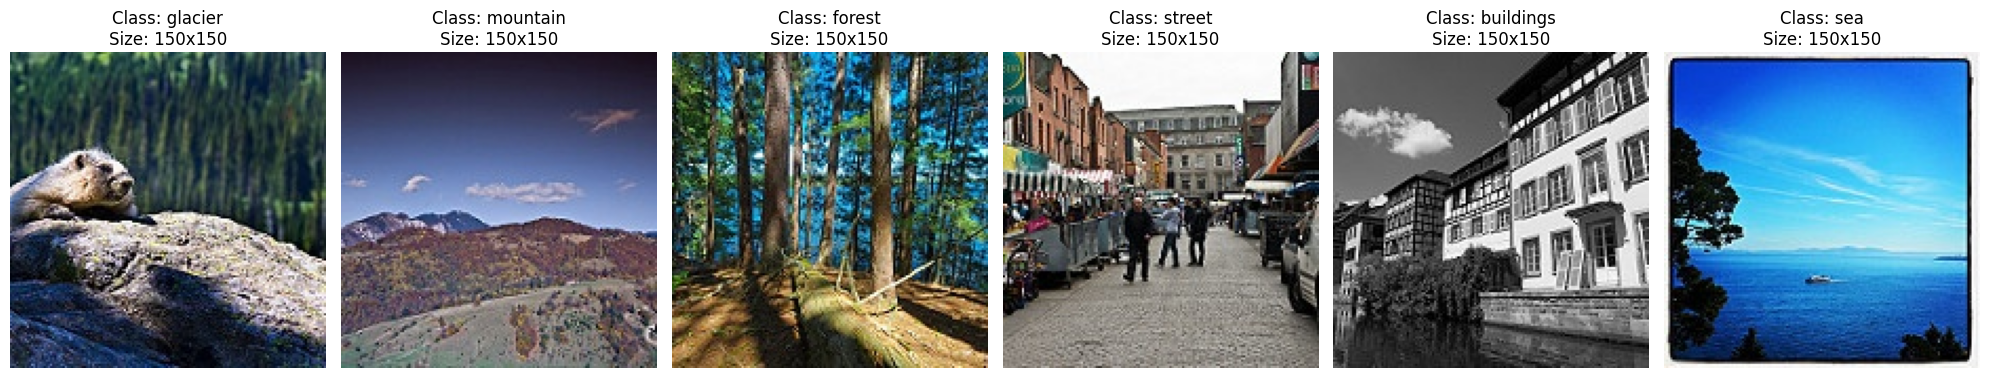

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# المسار اللي فيه المجلدات (classes)
data_dir = "/content/dataset/seg_train/seg_train"
classes = os.listdir(data_dir)

# تجهيز الشكل العام للعرض (Row واحد فيه عدد أعمدة بيساوي عدد الـ classes)
plt.figure(figsize=(20, 10))

for i, cls in enumerate(classes):
    # مسار الفولدر الخاص بالنوع الحالي
    cls_path = os.path.join(data_dir, cls)

    # اختيار أول صورة في الفولدر
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    # فتح الصورة عشان نعرف حجمها
    with Image.open(img_path) as img:
        width, height = img.size

        # عرض الصورة
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"Class: {cls}\nSize: {width}x{height}")
        plt.axis('off') # إخفاء المحاور عشان الشكل يبقى أنظف

plt.tight_layout()
plt.show()

### ​7. تجهيز تحويلات بيانات الاختبار | Test Data Transformations

**​العربية:**

نقوم هنا بتعريف سلسلة من العمليات التحويلية (Transforms) التي سيتم تطبيقها على صور الاختبار. تشمل هذه العمليات تغيير الحجم ليناسب متطلبات نموذج ResNet، وتحويل الصور إلى Tensors، ثم عمل معالجة معيارية (Normalization) باستخدام قيم ImageNet القياسية لضمان توافق البيانات مع النموذج المدرب مسبقاً.

**​English:**

In this step, we define a pipeline of transformations for the test dataset. These include resizing the images to meet ResNet requirements, converting them into Tensors, and applying standard ImageNet normalization. This ensures the input data is consistent with the pre-trained model's expectations.


In [7]:
import torch
from torchvision import datasets, transforms
import os

# 1. تحديد مسار مجلد الـ Test Data
# ملحوظة: تأكد إن المسار ده هو اللي موجود فعلياً عندك بناءً على فك الضغط فوق
test_dir = '/content/dataset/seg_test/seg_test' # المسار اللي جوه dataset

# 2. تعريف التحويلات المطلوبة للـ Test (بدون Augmentation)
test_transforms = transforms.Compose([
    # تكبير الصورة لـ 224x224 عشان تناسب ResNet
    transforms.Resize((224, 224)),

    # تحويل الصورة لتنسيق Tensor (قيم بين 0 و 1)
    transforms.ToTensor(),

    # الـ Normalization القياسي لـ ImageNet (Mean & Std)
    # دي القيم اللي الـ ResNet متدربة عليها جاهزة
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✅ تم تعريف التحويلات بنجاح.")



✅ تم تعريف التحويلات بنجاح.


### 8. إنشاء محمل بيانات الاختبار | Test DataLoader Creation

**​العربية:**

نقوم هنا بتحويل البيانات من مجرد ملفات على القرص إلى كائن DataLoader ذكي. يقوم هذا المحمل بتقسيم البيانات إلى مجموعات صغيرة (Batches)، مما يسمح للنموذج بمعالجتها بكفاءة دون استهلاك كامل ذاكرة الجهاز، كما يدعم المعالجة المتوازية باستخدام أنوية المعالج لتسريع عملية التحميل.

**​English:**

In this step, we convert the raw image files into a smart DataLoader object. It organizes the data into small Batches, enabling the model to process them efficiently without overloading the memory. Additionally, it supports multi-core parallel processing to speed up the data loading phase.

In [8]:
# 3. تحميل الـ Test Data وتطبيق التحويلات
test_data = datasets.ImageFolder(test_dir, transform=test_transforms)

print(f"✅ تم تحميل الـ Test Data. عدد الصور الإجمالي: {len(test_data)}")
print(f"📂 الأنواع المكتشفة (Classes): {test_data.classes}")

# 4. إنشاء الـ DataLoader للـ Test
batch_size = 32 # حجم الدفعة الواحدة (ممكن تغيره حسب ذاكرة الكارت عندك)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False, # في الـ Test مش بنحتاج نعمل shuffle عشان نقيم بترتيب ثابت
    num_workers=2, # عدد أنوية المعالج لتسريع التحميل
)

print(f"✅ تم إنشاء الـ DataLoader. عدد الدفعات (Batches): {len(test_loader)}")

✅ تم تحميل الـ Test Data. عدد الصور الإجمالي: 3000
📂 الأنواع المكتشفة (Classes): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
✅ تم إنشاء الـ DataLoader. عدد الدفعات (Batches): 94


### خاتمة مرحلة تجهيز البيانات | Data Preparation Wrap-up

**​العربية:**

بهذا نكون قد انتهينا من بناء خط الإمداد الكامل لبيانات الاختبار (Test Pipeline)؛ من تعريف التحويلات القياسية إلى إنشاء الـ DataLoader، لضمان تدفق البيانات للنموذج بأعلى كفاءة وجاهزية للتقييم النهائي.

**​English:**

We have successfully finalized the Test Pipeline; from defining standard transformations to initializing the DataLoader. The system is now fully optimized and ready to feed data into the model for high-performance evaluation and final testing.

### ​9. تحليل توزيع بيانات التدريب | Training Data Distribution Analysis

**​العربية:**

نقوم هنا بإجراء تحليل إحصائي وبصري لتوزيع الصور عبر الفئات المختلفة في مجموعة التدريب. تهدف هذه الخطوة إلى التأكد من توازن البيانات (Data Balance)، مما يضمن عدم تحيز النموذج لفئة معينة على حساب الأخرى، وهو أمر جوهري لدقة النتائج النهائية.

**​English:**

In this step, we perform a statistical and visual analysis of image distribution across different classes in the training set. This is crucial for verifying Data Balance, ensuring the model doesn't develop a bias toward any specific category, which is vital for overall performance accuracy.

/tmp/ipykernel_55613/3013248141.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')


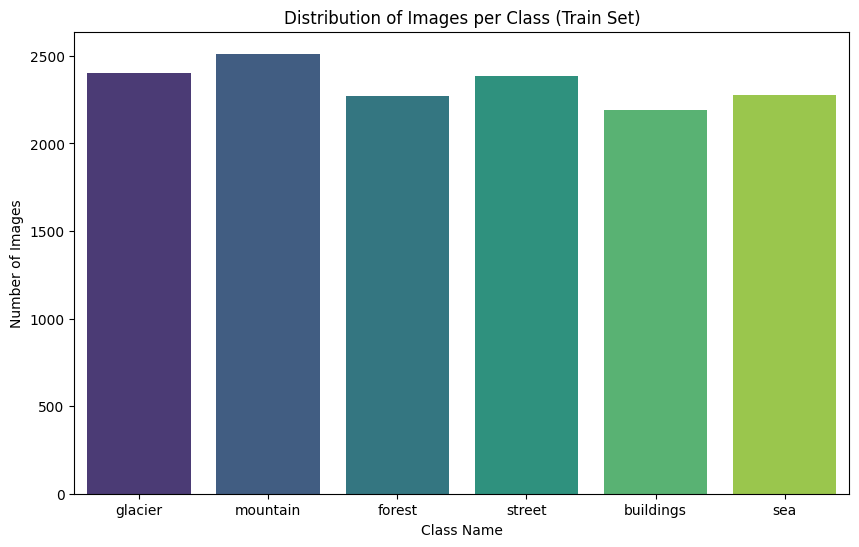

Counts: {'glacier': 2404, 'mountain': 2512, 'forest': 2271, 'street': 2382, 'buildings': 2191, 'sea': 2274}


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# مسار مجلد التدريب الأساسي
train_dir = "/content/dataset/seg_train/seg_train"
classes = os.listdir(train_dir)

# عد الصور في كل كلاس
counts = {}
for cls in classes:
    counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

# رسم بياني للتوزيع
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')
plt.title('Distribution of Images per Class (Train Set)')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.show()

print("Counts:", counts)

### ​10. تعزيز البيانات وتقسيمها | Data Augmentation & Splitting

**​العربية:**

نقوم هنا بتجهيز تحويلات متقدمة لبيانات التدريب (Data Augmentation) مثل الدوران وتغيير الإضاءة، لزيادة قدرة النموذج على التعميم. كما نقوم بحساب نسب تقسيم البيانات الأصلية لتوزيعها إلى مجموعتي تدريب (Training) وتحقق (Validation) بنسبة 80:20 لضمان مراقبة أداء النموذج بدقة أثناء التدريب.

**​English:**

In this step, we implement Data Augmentation techniques for the training set, such as rotation and color jittering, to enhance model generalization. We also calculate the indices to split the original dataset into Training and Validation sets with an 80:20 ratio, ensuring reliable performance monitoring.

In [10]:
from torch.utils.data import DataLoader, Subset
import numpy as np

# 1. تعريف الـ Transforms لكل جزء
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # قلب الصورة يمين وشمال
    transforms.RandomRotation(15),         # دوران خفيف
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # تغيير بسيط في الإضاءة
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. تحميل الداتا الأساسية (بدون transform في الأول)
full_dataset = datasets.ImageFolder(train_dir)





### ​11. تخصيص التحويلات والتقسيم النهائي | Custom Transforms & Final Splitting

**​العربية:**

نقوم هنا بتقسيم البيانات عشوائياً إلى مجموعتي تدريب وتحقق، مع بناء كلاس مخصص (Wrapper Class) لتطبيق تحويلات مختلفة على كل مجموعة بشكل مستقل. تضمن هذه الطريقة تطبيق تعزيز البيانات (Augmentation) على صور التدريب فقط، مع الحفاظ على صور التحقق في شكلها القياسي لضمان دقة التقييم.

**​English:**

In this step, we randomly split the data into Training and Validation subsets and implement a custom Wrapper Class to apply distinct transformations to each subset independently. This approach ensures that Data Augmentation is applied strictly to training images while keeping validation images in their standard form for reliable evaluation.

In [11]:
# 3. تقسيم الداتا (80% تدريب و 20% تحقق)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size]
)

# 4. الـ Wrapper Class عشان نطبق transform مختلف لكل جزء
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

### ​12. إنشاء محملات بيانات التدريب والتحقق | Training & Validation DataLoaders

**​العربية:**

في هذه الخطوة، نقوم بإنشاء الـ DataLoaders النهائية لمجموعتي التدريب والتحقق. نستخدم حجم دفعة (Batch Size) يساوي 32، مع تفعيل خاصية الخلط العشوائي (Shuffle) لبيانات التدريب لضمان عدم حفظ النموذج لترتيب الصور، وتعطيلها لبيانات التحقق للحصول على تقييم ثابت ومنظم.

**​English:**

In this step, we initialize the final DataLoaders for both Training and Validation sets. We set a Batch Size of 32, enabling Shuffle for the training data to prevent the model from memorizing the order, while keeping it disabled for validation to ensure a stable and organized evaluation process.

In [12]:
# تطبيق الـ Wrappers
train_data = ApplyTransform(Subset(full_dataset, train_indices), transform=train_transforms)
val_data = ApplyTransform(Subset(full_dataset, val_indices), transform=val_transforms)

# 5. إنشاء الـ DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

print(f"✅ تم تقسيم الداتا:")
print(f"🏠 صور التدريب: {len(train_data)}")
print(f"🧪 صور التحقق: {len(val_data)}")

✅ تم تقسيم الداتا:
🏠 صور التدريب: 11227
🧪 صور التحقق: 2807


### ​13. ملخص هندسة بيانات التدريب والتحقق | Training & Validation Pipeline Summary

**​العربية:**

بإتمام هذه الخطوة، نكون قد صممنا نظاماً متكاملاً لإمداد النموذج بالبيانات؛ يشمل تحليل التوزيع الإحصائي، وتطبيق تقنيات تعزيز الصور (Augmentation) لزيادة دقة التعميم، مع تقسيم البيانات بذكاء لضمان مراقبة حقيقية للأداء أثناء التعلم.

**​English:**

We have successfully engineered a robust Data Pipeline for training and validation. This includes statistical distribution analysis, advanced Data Augmentation for better generalization, and an optimized data splitting strategy to ensure reliable performance monitoring during the training phase.

### ​14. بناء هيكل النموذج باستخدام التعلم المنقول | Model Architecture via Transfer Learning

**​العربية:**

نقوم هنا ببناء هيكل النموذج بالاعتماد على ResNet50 المدرب مسبقاً على قاعدة بيانات ImageNet. قمنا بتجميد الأوزان الأساسية للحفاظ على القدرات الاستخراجية للموديل، مع إعادة تصميم طبقة التصنيف النهائية (Fully Connected Layer) لتناسب مشروعنا المكون من 6 فئات، مع إضافة طبقة Dropout لضمان استقرار النموذج ومنع الإفراط في التخصيص (Overfitting).

**​English:**

In this step, we construct our model using a pre-trained ResNet50 backbone. We freeze the base weights to leverage pre-learned features while redesigning the final classification head to match our 6-class task. A Dropout layer is integrated to enhance the model's robustness and prevent Overfitting.

In [13]:
import torch.nn as nn
from torchvision import models

# 1. تحميل موديل ResNet50 متدرب جاهز
model = models.resnet50(pretrained=True)

# 2. تجميد كل الطبقات (Frozen) عشان ما نضيعش الأوزان القديمة
for param in model.parameters():
    param.requires_grad = False

# 3. تعديل آخر طبقة (Fully Connected Layer)
# بنشوف الموديل كان بيطلع كام Feature في آخر طبقة (عادة 2048 في ResNet50)
num_ftrs = model.fc.in_features

# بنبدلها بطبقة جديدة مخصصة لـ 6 كلاسات فقط
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),    # طبقة وسيطة لزيادة الفهم
    nn.ReLU(),                   # دالة تنشيط
    # nn.Dropout(0.2),             # عشان نمنع الـ Overfitting
    nn.Linear(256, 6)            # المخرج النهائي (6 أنواع)
)

# 4. نقل الموديل للـ GPU لو متاح (عشان السرعة)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"✅ الموديل جاهز وشغال على: {device}")
print(model.fc) # عشان نتأكد من شكل الطبقة الأخيرة

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ الموديل جاهز وشغال على: cuda
Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=6, bias=True)
)


### ​15. تحديد معايير الفقد والمحسن | Loss Function & Optimizer Setup

**​العربية:**

في هذه المرحلة، نحدد الأدوات التي ستقود عملية تعلم النموذج. نستخدم Cross Entropy Loss كدالة فقد لتقييم دقة التوقعات في التصنيف المتعدد، ومحسن Adam لتحديث الأوزان بكفاءة. قمنا بتوجيه المحسن لتحديث بارامترات الطبقة الأخيرة فقط (Classifier)، مستفيدين من تجميد باقي الطبقات لتقليل زمن التدريب والحفاظ على الميزات المستخلصة مسبقاً.

**​English:**

At this stage, we define the core components of the training process. We utilize Cross Entropy Loss for multi-class classification evaluation and the Adam optimizer for efficient weight updates. The optimizer is specifically configured to update only the final classifier parameters, leveraging our frozen backbone to minimize training time while preserving pre-learned features.

In [14]:
import torch.optim as optim

# 1. تحديد دالة الفقد (Loss Function)
criterion = nn.CrossEntropyLoss()

# 2. تحديد المحسن (Optimizer)
# نركز فقط على بارامترات الطبقة الأخيرة (fc) لسرعة التدريب
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 3. إضافة مجدول سرعة التعلم (Learning Rate Scheduler) - "إضافة احترافية"
# سيقوم بتقليل سرعة التعلم بمقدار 10 أضعاف (gamma=0.1) كل 7 دورات (step_size=7)
# هذا يساعد الموديل على الاستقرار والوصول لأقل Loss ممكنة في نهاية التدريب
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("✅ جاهزون للعمل: تم ضبط المحسن، دالة الفقد، ومجدول سرعة التعلم.")

✅ جاهزون للعمل: تم ضبط المحسن، دالة الفقد، ومجدول سرعة التعلم.


### ​17. تنفيذ حلقة التدريب والتحقق | Training & Validation Loop Execution

**​العربية:**

هنا تبدأ عملية التعلم الفعلية؛ حيث يمر النموذج عبر البيانات لعدد 10 دورات (Epochs). في كل دورة، يمر النموذج بمرحلتين: مرحلة التدريب التي يتم فيها تحديث الأوزان بناءً على دالة الفقد، ومرحلة التحقق التي نختبر فيها قدرة النموذج على التعميم على بيانات لم يراها من قبل، مع حساب الدقة (Accuracy) ومعدل الخطأ (Loss) لكل منهما.

**​English:**

The actual learning process begins here, with the model iterating through the dataset for 10 Epochs. Each epoch consists of two phases: the Training Phase, where weights are updated based on the loss function, and the Validation Phase, where we evaluate the model's generalization on unseen data. Performance metrics, including Accuracy and Loss, are calculated for both stages

In [15]:
# 1. تجهيز القوائم لتخزين النتائج (أضفنا الجزء ده)
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 10 #

for epoch in range(epochs): #
    # --- مرحلة التدريب (Training Phase) ---
    model.train() #
    train_loss = 0.0 #
    train_corrects = 0 #

    for inputs, labels in train_loader: #
        inputs, labels = inputs.to(device), labels.to(device) #

        optimizer.zero_grad() #
        outputs = model(inputs) #
        loss = criterion(outputs, labels) #

        _, preds = torch.max(outputs, 1) #
        loss.backward() #
        optimizer.step() #

        train_loss += loss.item() * inputs.size(0) #
        train_corrects += torch.sum(preds == labels.data) #

    epoch_train_loss = train_loss / len(train_data) #
    epoch_train_acc = train_corrects.double() / len(train_data) #

    # --- مرحلة التحقق (Validation Phase) ---
    model.eval() #
    val_loss = 0.0 #
    val_corrects = 0 #

    with torch.no_grad(): #
        for inputs, labels in val_loader: #
            inputs, labels = inputs.to(device), labels.to(device) #
            outputs = model(inputs) #
            loss = criterion(outputs, labels) #

            _, preds = torch.max(outputs, 1) #
            val_loss += loss.item() * inputs.size(0) #
            val_corrects += torch.sum(preds == labels.data) #

    epoch_val_loss = val_loss / len(val_data) #
    epoch_val_acc = val_corrects.double() / len(val_data) #

    # 2. تخزين القيم في القوائم (أضفنا الجزء ده)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc.item()) # تحويل لـ item عشان الرسم
    val_accs.append(epoch_val_acc.item())

    # عرض النتائج
    print(f'Epoch {epoch+1}/{epochs}') #
    print(f'Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}') #
    print(f'Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}') #
    print('-' * 30) #



Epoch 1/10
Train Loss: 0.4969 | Train Acc: 0.8147
Val Loss: 0.3233 | Val Acc: 0.8789
------------------------------
Epoch 2/10
Train Loss: 0.3592 | Train Acc: 0.8644
Val Loss: 0.3278 | Val Acc: 0.8799
------------------------------
Epoch 3/10
Train Loss: 0.3435 | Train Acc: 0.8747
Val Loss: 0.2968 | Val Acc: 0.8878
------------------------------
Epoch 4/10
Train Loss: 0.3269 | Train Acc: 0.8769
Val Loss: 0.2823 | Val Acc: 0.8988
------------------------------
Epoch 5/10
Train Loss: 0.3179 | Train Acc: 0.8790
Val Loss: 0.3206 | Val Acc: 0.8828
------------------------------
Epoch 6/10
Train Loss: 0.3121 | Train Acc: 0.8849
Val Loss: 0.2727 | Val Acc: 0.9020
------------------------------
Epoch 7/10
Train Loss: 0.2937 | Train Acc: 0.8930
Val Loss: 0.2901 | Val Acc: 0.8942
------------------------------
Epoch 8/10
Train Loss: 0.2874 | Train Acc: 0.8917
Val Loss: 0.2679 | Val Acc: 0.9049
------------------------------
Epoch 9/10
Train Loss: 0.2877 | Train Acc: 0.8903
Val Loss: 0.2731 | Val

### ​18. تحليل ورسم منحنيات الأداء | Accuracy & Loss Visualization

**​العربية:**

في هذه الخطوة، نقوم بإنشاء دوال برمجية لرسم منحنيات الفقد (Loss) والدقة (Accuracy) لكل من مجموعتي التدريب والتحقق عبر جميع الدورات التدريبية. تساعدنا هذه الرسوم البيانية في اكتشاف حالات الإفراط في التخصيص (Overfitting) أو ضعف التعلم (Underfitting)، مما يوفر رؤية واضحة حول مدى استقرار النموذج وجودة تعميمه على البيانات الجديدة.

**​English:**

In this stage, we develop visualization functions to plot Loss and Accuracy curves for both training and validation sets across all epochs. These plots are essential for diagnosing potential Overfitting or Underfitting, providing clear insights into the model's stability and its ability to generalize to unseen data.

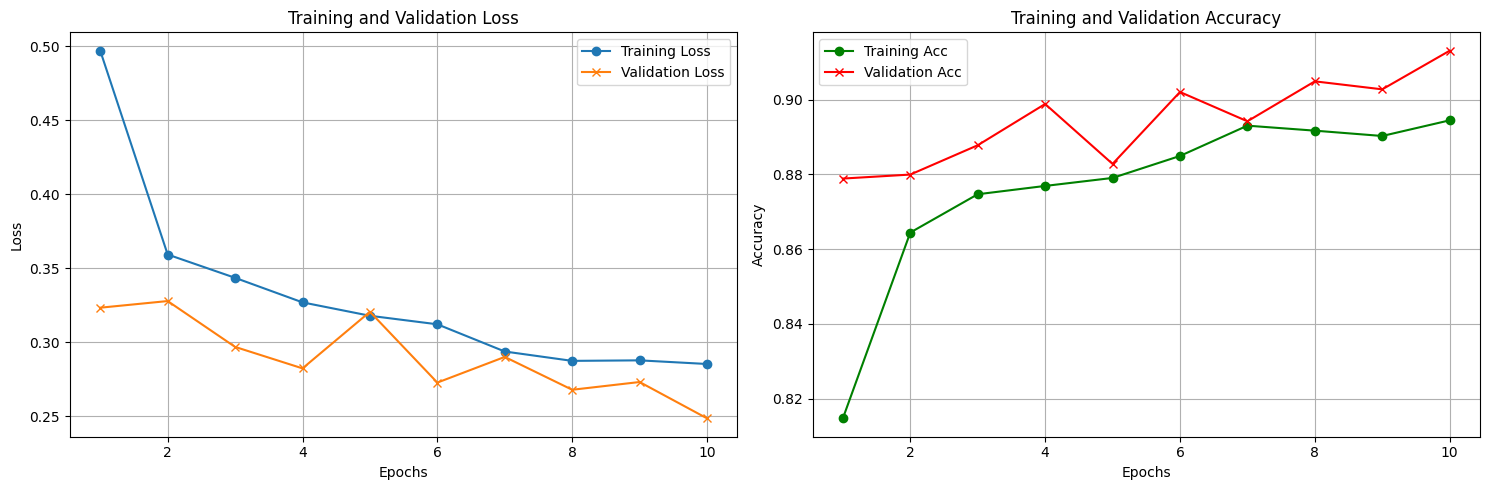

In [16]:
import matplotlib.pyplot as plt

def plot_performance(train_losses, val_losses, train_accs, val_accs):
    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(15, 5))

    # 1. رسم الـ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_losses, label='Validation Loss', marker='x')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. رسم الـ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accs, label='Training Acc', marker='o', color='green')
    plt.plot(epochs_range, val_accs, label='Validation Acc', marker='x', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# استدعاء الدالة عشان ترسم النتائج
plot_performance(train_losses, val_losses, train_accs, val_accs)

### ​📊 Training Performance Analysis | تحليل أداء التدريب

**​English:**

​The Loss Curves demonstrate a consistent downward trend, confirming that the model effectively minimized error and converged smoothly. The Accuracy Curves show that the model reached a high performance level, with the validation accuracy closely following the training progress, which indicates a well-generalized model without overfitting.

**​العربية:**

​توضح منحنيات الخسارة (Loss) انخفاضاً مستمراً، مما يؤكد قدرة الموديل على تقليل نسبة الخطأ والوصول لحالة الاستقرار (Convergence). كما تظهر منحنيات الدقة (Accuracy) وصول الموديل لمستوى أداء عالٍ، مع تقارب دقة التحقق (Validation) من دقة التدريب، مما يدل على قدرة الموديل على التعميم بشكل ممتاز دون الوقوع في مشكلة الـ Overfitting.

### ​19. التقييم النهائي: مصفوفة الارتباك وتقرير التصنيف | Final Evaluation: Confusion Matrix & Classification Report

**​العربية:**

تعتبر هذه المرحلة هي الاختبار الحقيقي للنموذج على بيانات الاختبار المستقلة. نقوم هنا بإنشاء Classification Report للحصول على تفاصيل دقيقة حول الدقة (Precision) والاستدعاء (Recall) لكل فئة، بالإضافة إلى رسم Confusion Matrix (مصفوفة الارتباك) التي توضح لنا بوضوح أين يخطئ النموذج وأي الفئات يتم الخلط بينها، مما يساعدنا في تحسين الأداء مستقبلاً.

**​English:**

This stage represents the definitive test of the model using an independent test dataset. We generate a Classification Report to obtain detailed metrics like Precision and Recall for each category. Additionally, we plot a Confusion Matrix to visualize the model's errors and identify which classes are being misclassified, providing critical insights for future refinements.


📊 Classification Report:
              precision    recall  f1-score   support

   buildings       0.91      0.91      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.81      0.85       553
    mountain       0.84      0.88      0.86       525
         sea       0.90      0.97      0.94       510
      street       0.93      0.91      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



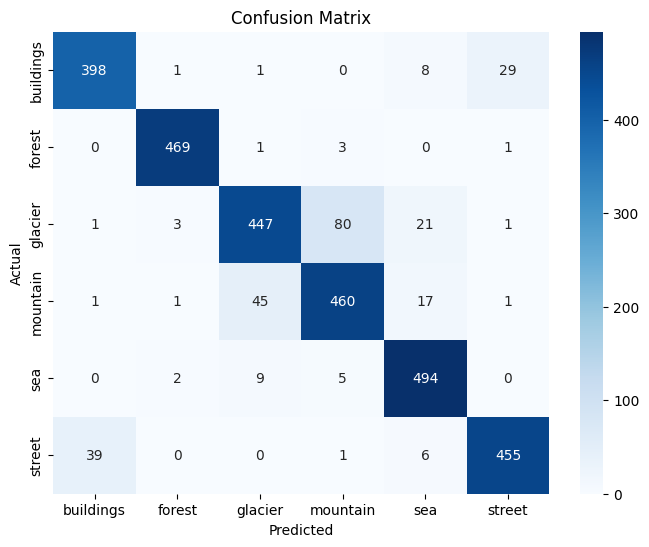

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def show_final_evaluation(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# لما تخلص تدريب خالص، هتناديها كدة:
show_final_evaluation(model, test_loader, test_data.classes)

### ​📉 Model Evaluation | تقييم أداء النموذج

**​English:**

​The Classification Report shows an overall accuracy of 91%, with high precision and recall across most classes, especially the "Forest" category. The Confusion Matrix further confirms this strong performance, as the majority of predictions lie on the main diagonal. While there is minor confusion between "Glacier" and "Mountain" due to visual similarities, the model effectively distinguishes between most distinct environments.

**​العربية:**

​يوضح تقرير التصنيف (Classification Report) أن الدقة الإجمالية للموديل بلغت 91%، مع قيم مرتفعة لـ Precision و Recall في معظم الفئات، وخاصة فئة "Forest". وتؤكد مصفوفة الارتباك (Confusion Matrix) هذا الأداء القوي، حيث تتركز معظم التوقعات الصحيحة على القطر الرئيسي للمصفوفة. وبالرغم من وجود تداخل بسيط بين فئتي "Glacier" و "Mountain" نظراً للتشابه البصري بينهما، إلا أن الموديل أظهر كفاءة عالية في التمييز بين البيئات المختلفة

### ​20. تجربة النموذج على صور عشوائية | Random Image Prediction & Inference

**​العربية:**

تمثل هذه الخطوة النهائية مرحلة الاستدلال (Inference)، حيث نختار مجموعة من الصور العشوائية من مجلد التوقعات ونمررها عبر النموذج لاختبار كفاءته في الوقت الفعلي. نقوم بمعالجة الصور بنفس التحويلات المستخدمة في التدريب، ثم نعرض الصورة مع الفئة التي توقعها النموذج، مما يعطينا تأكيداً بصرياً ملموساً على دقة الأداء.

**​English:**

This final step represents the Inference phase, where we select a set of random images from the prediction folder and pass them through the model to test its real-time performance. We process the images using the same transforms as in training, then display each image alongside its predicted class, providing a tangible visual confirmation of the model's accuracy.

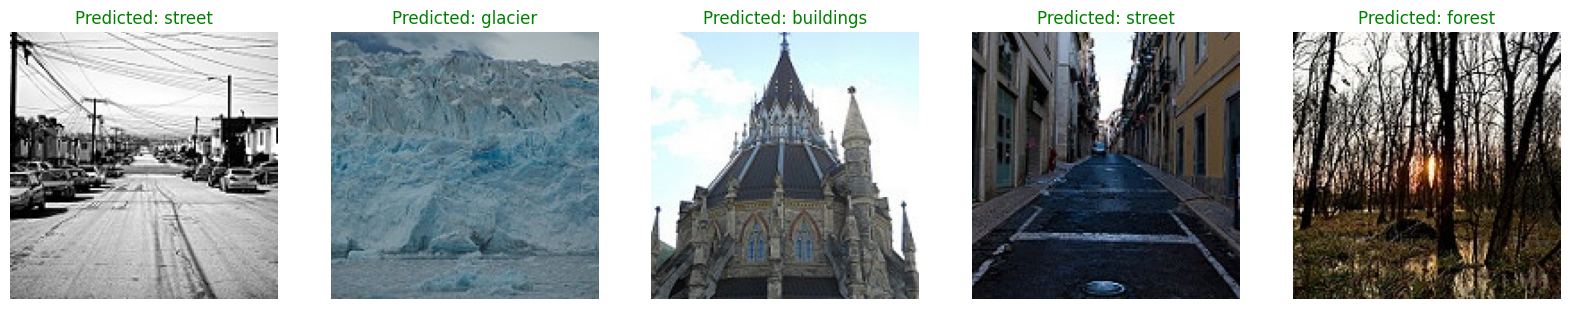

In [18]:
import random
from PIL import Image

def predict_random_images(model, pred_dir, transform, classes, num_images=5):
    model.eval()
    all_images = os.listdir(pred_dir)
    random_samples = random.sample(all_images, num_images)

    plt.figure(figsize=(20, 10))

    for i, img_name in enumerate(random_samples):
        img_path = os.path.join(pred_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        # تجهيز الصورة للموديل
        input_tensor = transform(image).unsqueeze(0).to(device)

        # التوقع
        with torch.no_grad():
            output = model(input_tensor)
            _, preds = torch.max(output, 1)
            predicted_class = classes[preds.item()]

        # العرض
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"Predicted: {predicted_class}", color='green', fontsize=12)
        plt.axis('off')

    plt.show()

# لما تيجي تشغله هتنادي عليه كدة:
predict_random_images(model, '/content/dataset/seg_pred/seg_pred', test_transforms, test_data.classes)

### ​🔮 Advanced Prediction & Probability Analysis | التوقع المتقدم وتحليل الاحتمالات

**​English:**

​Beyond simple classification, this section utilizes the Softmax output to visualize the model's confidence levels for each prediction. By displaying the top 3 class probabilities alongside each image, we can identify cases where the model is highly certain or when it struggles to differentiate between visually similar classes like "Street" and "Buildings".

**​العربية:**

​أبعد من مجرد التصنيف البسيط، يستخدم هذا القسم مخرجات دالة Softmax لعرض مستويات ثقة الموديل في كل توقع بشكل مرئي. من خلال عرض احتمالات أفضل 3 فئات بجانب كل صورة، يمكننا تحديد الحالات التي يكون فيها الموديل واثقاً تماماً أو الحالات التي يواجه فيها صعوبة في التمييز بين الفئات المتشابهة بصرياً مثل "Street" و "Buildings".

### ​21. التوقع المتقدم وتحليل الاحتمالات | Advanced Prediction & Probability Analysis

**​العربية:**

تتيح هذه الدالة فحصاً دقيقاً لقرارات النموذج؛ حيث لا تكتفي بإظهار الفئة المتوقعة، بل تقوم بحساب احتمالات أفضل 3 فئات مرشحة باستخدام دالة Softmax. يتم عرض الصورة بجانب رسم بياني يوضح نسبة اليقين لكل فئة، مما يساعد في فهم الحالات التي قد يشعر فيها النموذج بالارتباك بين فئتين متشابهتين.

**​English:**

This function enables a meticulous examination of the model's decision-making process. Beyond just predicting a class, it calculates the probabilities of the top 3 candidates using the Softmax function. By displaying the image alongside a bar chart of these probabilities, we gain insights into the model's confidence levels and identify instances where it might be torn between similar categories.

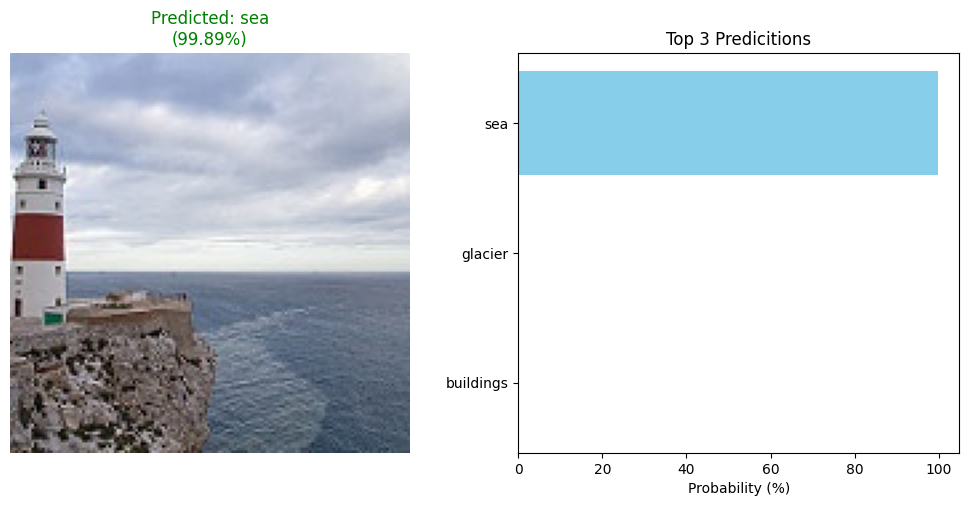

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_prediction(model, img_path, transform, classes, device):
    # فتح الصورة وتجهيزها
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # التوقع (Inference)
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        # تحويل المخرج لـ probabilities باستخدام Softmax
        probabilities = torch.nn.functional.softmax(output, dim=1)[0]

    # الحصول على أعلى 3 احتمالات
    top_probs, top_indices = probabilities.topk(3)

    # تحويل البيانات لـ numpy عشان الرسم
    top_probs = top_probs.cpu().numpy()
    top_indices = top_indices.cpu().numpy()
    top_classes = [classes[idx] for idx in top_indices]

    # --- الرسم البياني (Visualization) ---
    plt.figure(figsize=(10, 5))

    # 1. عرض الصورة
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Predicted: {top_classes[0]}\n({top_probs[0]*100:.2f}%)", color='green')
    plt.axis('off')

    # 2. عرض الـ Bar Chart للاحتمالات
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(top_classes))
    plt.barh(y_pos, top_probs * 100, align='center', color='skyblue')
    plt.yticks(y_pos, top_classes)
    plt.xlabel('Probability (%)')
    plt.title('Top 3 Predicitions')
    plt.gca().invert_yaxis()  # عشان أعلى كلاس يبقى فوق

    plt.tight_layout()
    plt.show()

# لما تيجي تشغله بكرة هتنادي عليه كدة:
path_to_image = '/content/dataset/seg_test/seg_test/sea/20077.jpg' # اختار أي صورة
visualize_prediction(model, path_to_image, test_transforms, test_data.classes, device)

### ​👁️ Visualizing Model Decisions | تفسير قرارات النموذج

**​English:**

​This final stage combines Grad-CAM heatmaps with Top-3 Probability bar charts to provide a comprehensive view of the model's reasoning. The heatmap highlights the specific pixels that triggered the classification, while the probability chart shows how confident the model is compared to other potential classes. For instance, it can achieve a confidence level as high as 99.89% for clear-cut classes like "Sea".

**​العربية:**

​تدمج هذه المرحلة النهائية بين الخرائط الحرارية لتقنية Grad-CAM والرسوم البيانية لـ أفضل 3 احتمالات لتقديم رؤية شاملة لكيفية اتخاذ الموديل لقراره. توضح الخريطة الحرارية البكسلات المحددة التي أدت لعملية التصنيف، بينما يوضح مخطط الاحتمالات مدى ثقة الموديل مقارنة بالفئات الأخرى المحتملة. على سبيل المثال، يمكن للموديل أن يصل لمستوى ثقة مرتفع جداً يصل إلى 99.89% في الفئات الواضحة مثل "البحر".

### ​22. تفسير قرارات النموذج باستخدام تقنية Grad-CAM | Visualizing Model Decisions

**​العربية:**

تعد تقنية Grad-CAM (تدرج خرائط تنشيط الفئات) أداة قوية لتفسير وفهم سلوك الشبكات العصبية العميقة. بدلاً من التعامل مع النموذج كـ "صندوق أسود"، تسمح لنا هذه التقنية برؤية "مناطق الاهتمام" التي ركز عليها النموذج لتحديد فئة معينة. نقوم هنا باستخراج الخرائط الحرارية (Heatmaps) من الطبقة التلافيفية الأخيرة في ResNet50، ودمجها مع الصورة الأصلية لنعرف بالضبط ما هي الأجزاء التي دفعت النموذج لهذا التوقع.

**​English:**

Grad-CAM (Gradient-weighted Class Activation Mapping) is a sophisticated technique used to interpret and understand the behavior of Deep Neural Networks. Instead of treating the model as a "black box," it highlights the specific "regions of interest" the model focused on to make its prediction. By extracting Heatmaps from the final convolutional layer of ResNet50 and overlaying them on the original image, we can visualize exactly which features influenced the model's decision

/tmp/ipykernel_55613/1570830252.py:30: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  grad = activations[0].grad # مش بنستخدم ده مباشرة، بنستخدم الـ hook


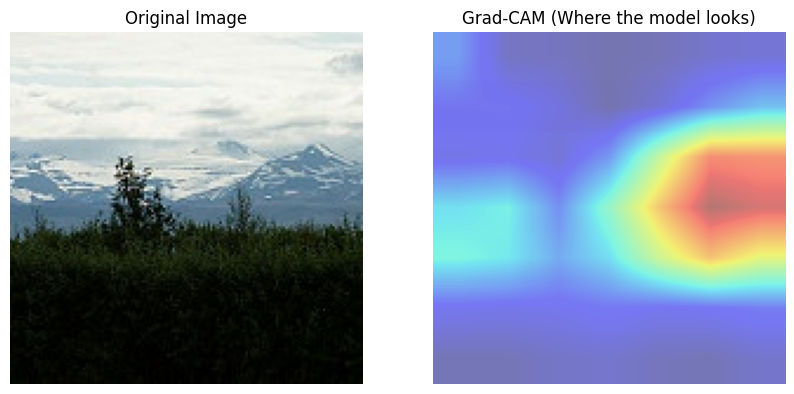

In [31]:
import torch.nn.functional as F

def generate_grad_cam(model, input_tensor, target_layer):
    # مصفوفات لتخزين الـ gradients والـ activations
    gradients = []
    activations = []

    def save_gradient(grad):
        gradients.append(grad)

    def save_activation(module, input, output):
        activations.append(output)

    # وضع الـ Hook على آخر طبقة Convolutional في ResNet50 (layer4)
    hook_handle = target_layer.register_forward_hook(save_activation)

    # 1. Forward Pass
    model.eval()
    output = model(input_tensor)

    # اختيار أعلى كلاس (أو كلاس معين أنت عاوزه)
    target_class = output.argmax(dim=1)
    target_output = output[:, target_class]

    # 2. Backward Pass لسحب الـ Gradients
    model.zero_grad()
    target_output.backward(retain_graph=True)

    # سحب الـ gradients من الـ output الخاص بالطبقة
    grad = activations[0].grad # مش بنستخدم ده مباشرة، بنستخدم الـ hook
    # تصحيح بسيط: الـ gradients بنجيبها بـ register_hook على الـ output
    activations[0].register_hook(save_gradient)
    target_output.backward()

    # حساب الـ Weights (متوسط الـ gradients)
    weights = torch.mean(gradients[0], dim=(2, 3), keepdim=True)

    # حساب الـ Heatmap
    cam = torch.sum(weights * activations[0], dim=1, keepdim=True)
    cam = F.relu(cam) # بناخد التأثير الإيجابي بس

    # Normalization للـ heatmap عشان تبقى بين 0 و 1
    cam = cam - cam.min()
    cam = cam / cam.max()

    hook_handle.remove() # تنظيف الـ hook
    return cam.detach().cpu().numpy()[0, 0]

# --- كود العرض (Visualizing) ---
def plot_grad_cam(model, img_path, transform, classes):
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True # مهم جداً للـ CAM

    # بنستهدف آخر طبقة في ResNet50 وهي layer4
    heatmap = generate_grad_cam(model, input_tensor, model.layer4)

    # رسم النتائج
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5, interpolation='bilinear')  # تركيب الخريطة فوق الصورة
    plt.title("Grad-CAM (Where the model looks)")
    plt.axis('off')
    plt.show()


# اختار مسار أي صورة من الداتا اللي عندك عشان تجرب عليها
img_path = "/content/dataset/seg_test/seg_test/mountain/20129.jpg"
plot_grad_cam(model, img_path, val_transforms, classes)

/tmp/ipykernel_55613/1570830252.py:30: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  grad = activations[0].grad # مش بنستخدم ده مباشرة، بنستخدم الـ hook


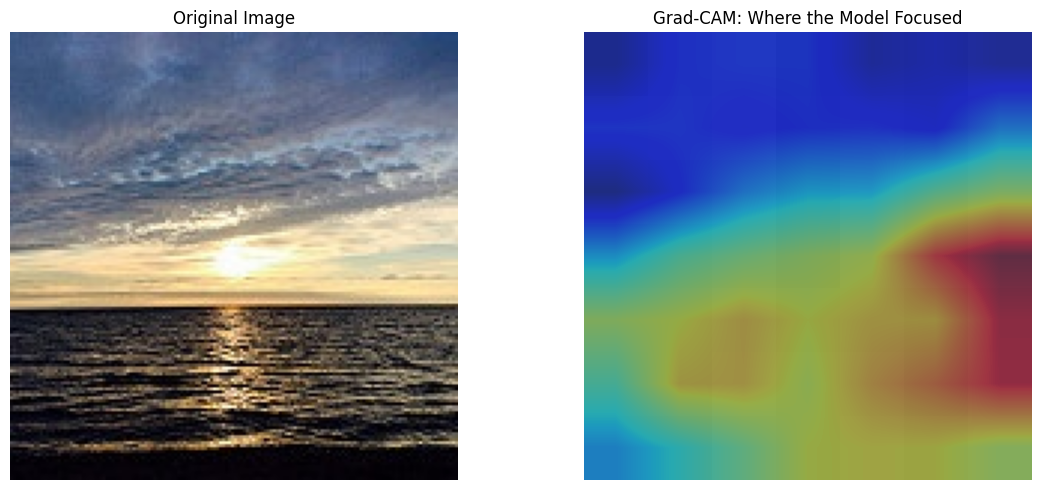

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

def plot_grad_cam(model, img_path, transform, classes):
    # 1. تجهيز الصورة
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True #

    # 2. استخراج الـ Heatmap (باستخدام layer4 في ResNet50)
    #
    heatmap = generate_grad_cam(model, input_tensor, model.layer4)

    # 3. الرسم الاحترافي
    plt.figure(figsize=(12, 5))

    # الصورة الأصلية
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # صورة الـ Grad-CAM مع التنعيم (Bilinear Interpolation)
    plt.subplot(1, 2, 2)
    plt.imshow(img) # رسم الصورة الأصلية كخلفية

    # رسم الـ Heatmap فوقها مع تسييح الألوان وتحديد الشفافية alpha
    #
    plt.imshow(heatmap, cmap='jet', alpha=0.5, interpolation='bilinear')

    plt.title("Grad-CAM: Where the Model Focused")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# الآن استدعي الدالة بالمسار بتاعك
img_path = "/content/dataset/seg_test/seg_test/sea/20402.jpg" #
plot_grad_cam(model, img_path, val_transforms, classes) #

/tmp/ipykernel_55613/4049323872.py:30: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  grad = activations[0].grad # مش بنستخدم ده مباشرة، بنستخدم الـ hook


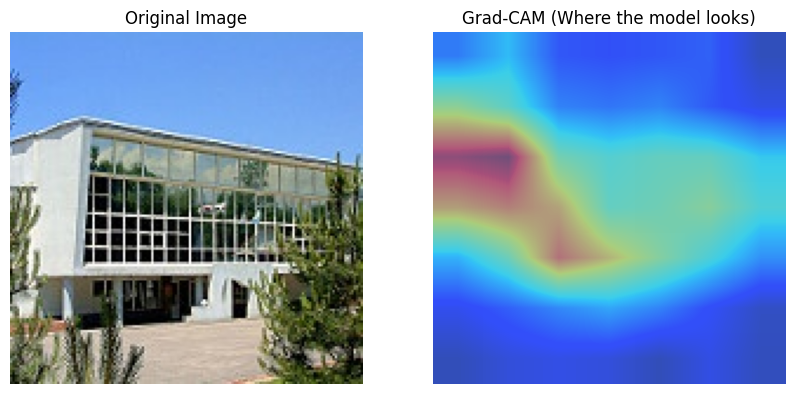

In [29]:
import torch.nn.functional as F

def generate_grad_cam(model, input_tensor, target_layer):
    # مصفوفات لتخزين الـ gradients والـ activations
    gradients = []
    activations = []

    def save_gradient(grad):
        gradients.append(grad)

    def save_activation(module, input, output):
        activations.append(output)

    # وضع الـ Hook على آخر طبقة Convolutional في ResNet50 (layer4)
    hook_handle = target_layer.register_forward_hook(save_activation)

    # 1. Forward Pass
    model.eval()
    output = model(input_tensor)

    # اختيار أعلى كلاس (أو كلاس معين أنت عاوزه)
    target_class = output.argmax(dim=1)
    target_output = output[:, target_class]

    # 2. Backward Pass لسحب الـ Gradients
    model.zero_grad()
    target_output.backward(retain_graph=True)

    # سحب الـ gradients من الـ output الخاص بالطبقة
    grad = activations[0].grad # مش بنستخدم ده مباشرة، بنستخدم الـ hook
    # تصحيح بسيط: الـ gradients بنجيبها بـ register_hook على الـ output
    activations[0].register_hook(save_gradient)
    target_output.backward()

    # حساب الـ Weights (متوسط الـ gradients)
    weights = torch.mean(gradients[0], dim=(2, 3), keepdim=True)

    # حساب الـ Heatmap
    cam = torch.sum(weights * activations[0], dim=1, keepdim=True)
    cam = F.relu(cam) # بناخد التأثير الإيجابي بس

    # Normalization للـ heatmap عشان تبقى بين 0 و 1
    cam = cam - cam.min()
    cam = cam / cam.max()

    hook_handle.remove() # تنظيف الـ hook
    return cam.detach().cpu().numpy()[0, 0]

# --- كود العرض (Visualizing) ---
def plot_grad_cam(model, img_path, transform, classes):
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad = True # مهم جداً للـ CAM

    # بنستهدف آخر طبقة في ResNet50 وهي layer4
    heatmap = generate_grad_cam(model, input_tensor, model.layer4)

    # رسم النتائج
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5, interpolation='bilinear')  # تركيب الخريطة فوق الصورة
    plt.title("Grad-CAM (Where the model looks)")
    plt.axis('off')
    plt.show()


# اختار مسار أي صورة من الداتا اللي عندك عشان تجرب عليها
img_path = "/content/dataset/seg_test/seg_test/buildings/20078.jpg"
plot_grad_cam(model, img_path, val_transforms, classes)

### ​🔍 Model Interpretability with Grad-CAM

​To ensure the model is making decisions based on relevant features rather than background noise, I implemented Grad-CAM (Gradient-weighted Class Activation Mapping).

**​How it Works:**

​Feature Extraction: It uses the gradients of the target class (e.g., Mountain, Sea, Forest) flowing into the last convolutional layer (layer4 or layer3 of ResNet50).
​Heatmap Generation: We calculate the importance of each neuron to the final prediction and produce a coarse localization map.
​Visualization: The heatmap is superimposed on the original image using Bilinear Interpolation for a smooth, professional finish.

**​💡 تفسير النتائج بالعربية:**

​استخدمت تقنية Grad-CAM لزيادة شفافية الموديل وفهم كيفية اتخاذ القرار:
​المناطق الدافئة (الأحمر/الأصفر): تمثل الأجزاء التي ركز عليها الموديل لتصنيف الصورة (مثل قمم الجبال أو أفق البحر).
​الدقة: باستخدام bilinear interpolation وتجربة طبقات مختلفة، تمكنت من الحصول على خريطة حرارية دقيقة توضح كفاءة التدريب.

In [46]:
import torch

# حفظ الأوزان فقط (الطريقة الاحترافية والموصى بها)
torch.save(model.state_dict(), 'Deep_Scene_Vision_v1.pth')

# حفظ الموديل بالكامل (الأوزان + الهيكل)
torch.save(model, 'Full_Model_Scene.pt')

In [48]:
# تحديد الجهاز المستخدم (GPU لو متاح، وإلا CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()
# تأكد إن الموديل على الجهاز الصح
model.to(device)

# التعديل المهم هنا: ضيف .to(device) للبيانات المدخلة
example_input = torch.rand(1, 3, 224, 224).to(device) #

traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("model_mobile_optimized.pt")